# Anomaly Detection on Pump Sensor Data
Unsupervised anomaly detection on multivariate time-series sensor data from an industrial pump.
Two approaches: Isolation Forest (classical) and LSTM Autoencoder (deep learning).
Dataset: Pump Sensor Data (Kaggle) — 52 sensors, ~220,000 timesteps.

**Note:** This notebook runs on Google Colab. Data is stored in temporary session storage
and must be re-downloaded at the start of each session. Run the Kaggle credentials
and data download cells before proceeding.

In [3]:
import os
import json
from getpass import getpass

os.makedirs(os.path.expanduser("~/.config/kaggle"), exist_ok=True)

username = input("Kaggle username: ")
key = getpass("Kaggle API token: ")

kaggle_config = {"username": username, "key": key}

with open(os.path.expanduser("~/.config/kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_config, f)

os.chmod(os.path.expanduser("~/.config/kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured.")

Kaggle username: darrencameron
Kaggle API token: ··········
Kaggle credentials configured.


In [6]:
# Download data
os.makedirs("data/raw", exist_ok=True)
!pip install -q kaggle
!kaggle datasets download -d nphantawee/pump-sensor-data
!unzip -q pump-sensor-data.zip -d data/raw/
!ls data/raw/

Dataset URL: https://www.kaggle.com/datasets/nphantawee/pump-sensor-data
License(s): unknown
100% 37.1M/37.1M [00:03<00:00, 12.9MB/s]

sensor.csv


## Imports

In [4]:
import os
import json
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

numpy: 2.0.2
pandas: 2.2.2
torch: 2.10.0+cpu


## Load Data and Exploration

In [7]:
df = pd.read_csv("data/raw/sensor.csv")
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(220320, 55)
   Unnamed: 0            timestamp  sensor_00  sensor_01  sensor_02  \
0           0  2018-04-01 00:00:00   2.465394   47.09201    53.2118   
1           1  2018-04-01 00:01:00   2.465394   47.09201    53.2118   
2           2  2018-04-01 00:02:00   2.444734   47.35243    53.2118   
3           3  2018-04-01 00:03:00   2.460474   47.09201    53.1684   
4           4  2018-04-01 00:04:00   2.445718   47.13541    53.2118   

   sensor_03  sensor_04  sensor_05  sensor_06  sensor_07  ...  sensor_43  \
0  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
1  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
2  46.397570   638.8889   73.54598   13.32465   16.03733  ...   41.66666   
3  46.397568   628.1250   76.98898   13.31742   16.24711  ...   40.88541   
4  46.397568   636.4583   76.58897   13.35359   16.21094  ...   41.40625   

   sensor_44  sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  \
0  39.641200   65.68287   50.925

In [8]:
print(df["machine_status"].value_counts())
print(f"\nTotal rows: {len(df)}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Total rows: 220320

Date range: 2018-04-01 00:00:00 to 2018-08-31 23:59:00


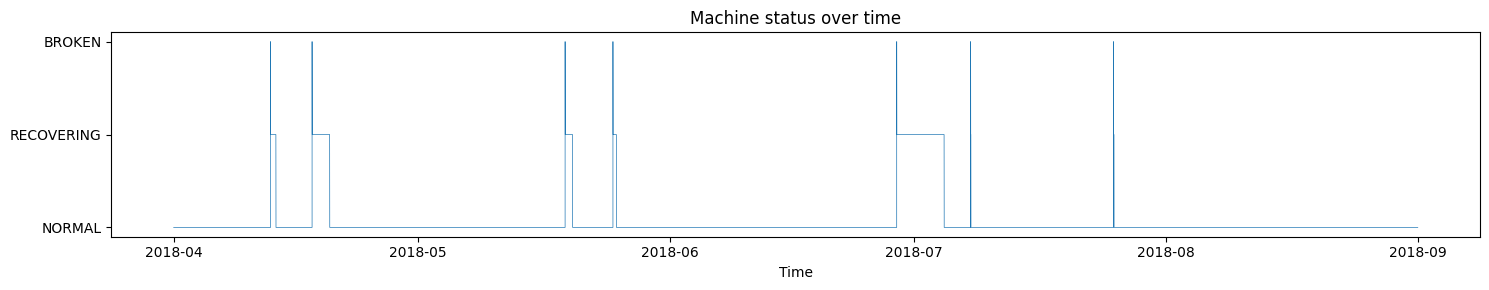

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Plot machine status over time
status_map = {"NORMAL": 0, "RECOVERING": 1, "BROKEN": 2}
df["status_code"] = df["machine_status"].map(status_map)

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df["timestamp"], df["status_code"], linewidth=0.5)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
ax.set_xlabel("Time")
ax.set_title("Machine status over time")
plt.tight_layout()
plt.savefig("data/machine_status.png", dpi=150, bbox_inches="tight")
plt.show()

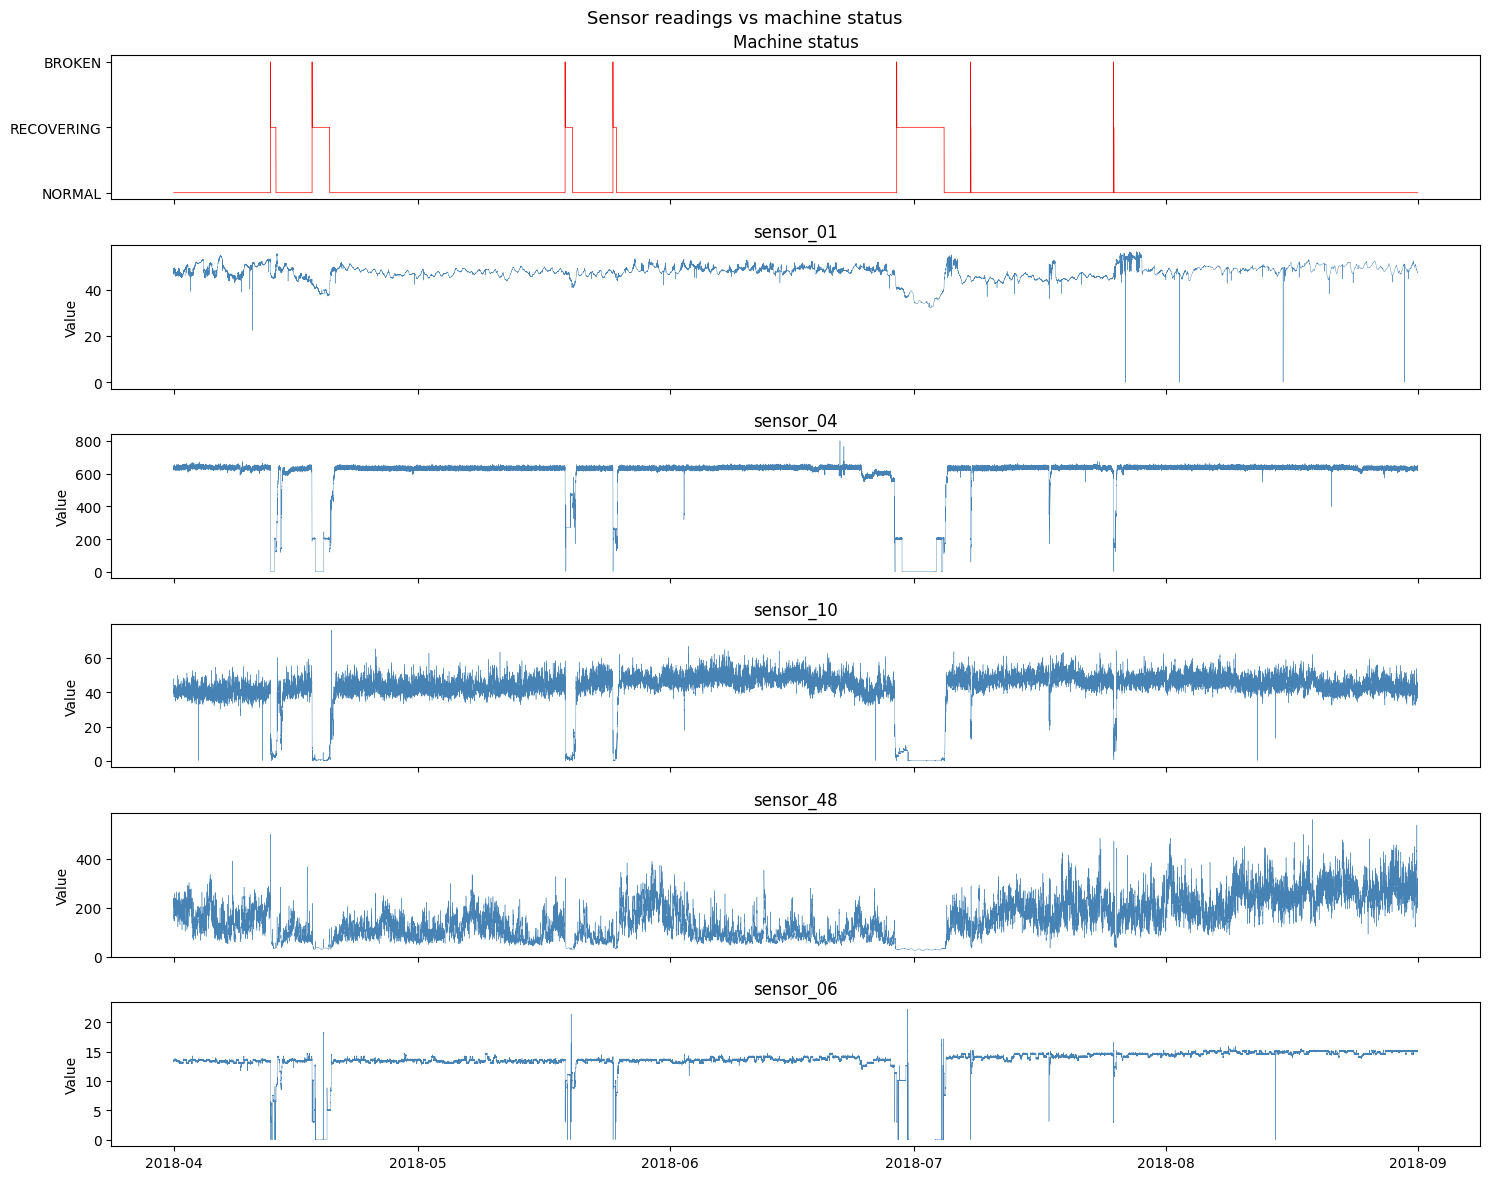

In [12]:
fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True)

# Machine status
axes[0].plot(df["timestamp"], df["status_code"], linewidth=0.5, color="red")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
axes[0].set_title("Machine status")

# A few representative sensors
for ax, sensor in zip(axes[1:], ["sensor_01", "sensor_04", "sensor_10",
                                 "sensor_48", "sensor_06"]):
    ax.plot(df["timestamp"], df[sensor], linewidth=0.3, color="steelblue")
    ax.set_title(sensor)
    ax.set_ylabel("Value")

plt.suptitle("Sensor readings vs machine status", fontsize=13)
plt.tight_layout()
plt.savefig("data/sensor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Look at the BROKEN timesteps in detail
broken = df[df["machine_status"] == "BROKEN"][["timestamp", "machine_status"]]
print(broken)

# Check the timesteps immediately before and after each BROKEN point
for idx in broken.index:
    window = df.loc[max(0, idx-3):idx+3, ["timestamp", "machine_status"]]
    print(window)
    print()

                 timestamp machine_status
17155  2018-04-12 21:55:00         BROKEN
24510  2018-04-18 00:30:00         BROKEN
69318  2018-05-19 03:18:00         BROKEN
77790  2018-05-25 00:30:00         BROKEN
128040 2018-06-28 22:00:00         BROKEN
141131 2018-07-08 00:11:00         BROKEN
166440 2018-07-25 14:00:00         BROKEN
                timestamp machine_status
17152 2018-04-12 21:52:00         NORMAL
17153 2018-04-12 21:53:00         NORMAL
17154 2018-04-12 21:54:00         NORMAL
17155 2018-04-12 21:55:00         BROKEN
17156 2018-04-12 21:56:00     RECOVERING
17157 2018-04-12 21:57:00     RECOVERING
17158 2018-04-12 21:58:00     RECOVERING

                timestamp machine_status
24507 2018-04-18 00:27:00         NORMAL
24508 2018-04-18 00:28:00         NORMAL
24509 2018-04-18 00:29:00         NORMAL
24510 2018-04-18 00:30:00         BROKEN
24511 2018-04-18 00:31:00     RECOVERING
24512 2018-04-18 00:32:00     RECOVERING
24513 2018-04-18 00:33:00     RECOVERING

      

### Dataset description
- ~5 months of pump operation, April to September 2018, at 1-minute resolution
- 220,320 timesteps, 52 sensors recording continuous operational parameters
- Machine status has three states: NORMAL (205,836), RECOVERING (14,477), BROKEN (7)
- 5 to 6 distinct fault events visible across the period, each brief but followed by extended recovery periods
- Sensor responses to fault events vary: some sensors (e.g. sensor_04) track fault events closely, others are noisier or less discriminating
- Missing data visible in several sensors (e.g. sensor_06) — apparent as sudden drops, not true zero readings
- sensor_15 is entirely missing and will be dropped; sensor_50 has 35% missingness and will also be dropped

### Notes on machine status
- Only 7 BROKEN timesteps across the entire dataset — each is a single isolated point
- Every BROKEN point follows the pattern: NORMAL → BROKEN (1 min) → RECOVERING
- BROKEN represents the moment of failure, RECOVERING the aftermath
- Two apparent spikes on the status plot with no visible recovery were an artefact of plot resolution
- For modelling: NORMAL = normal class, BROKEN + RECOVERING = anomalous class

## Step 3 - Data Cleaning

In [15]:
# Drop entirely missing or high missingness sensors
df = df.drop(columns=["sensor_15", "sensor_50", "Unnamed: 0"])

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Forward fill remaining missing values
df = df.ffill()

# Verify no missing values remain
print("Remaining missing values:")
print(df.isnull().sum().sum())
print(f"\nShape after cleaning: {df.shape}")

Remaining missing values:
0

Shape after cleaning: (220320, 53)


### Step 3 results
- Dropped sensor_15 (100% missing), sensor_50 (35% missing), and unnamed index column
- Forward filled remaining missing values across all other sensors
- Final shape: 220,320 rows × 53 columns (timestamp, 51 sensors, machine_status)
- No missing values remain

## Step 4 — Feature Engineering

In [16]:
# Binary anomaly label
df["anomaly"] = (df["machine_status"] != "NORMAL").astype(int)
print("Anomaly label distribution:")
print(df["anomaly"].value_counts())

# Select sensor columns
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(f"\nNumber of sensors: {len(sensor_cols)}")

# Scale features
scaler = StandardScaler()
X = df[sensor_cols].values
X_scaled = scaler.fit_transform(X)

# Train on NORMAL only, test on full dataset
normal_mask = df["anomaly"] == 0
X_train = X_scaled[normal_mask]
X_test = X_scaled
y_test = df["anomaly"].values

print(f"\nTrain (normal only): {X_train.shape}")
print(f"Test (full dataset): {X_test.shape}")

Anomaly label distribution:
anomaly
0    205836
1     14484
Name: count, dtype: int64

Number of sensors: 50

Train (normal only): (205836, 50)
Test (full dataset): (220320, 50)


In [17]:
# Check sensor cols
print(sensor_cols)

['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_51']


### Step 4 results
- Binary anomaly label: 205,836 normal (0), 14,484 anomalous (1) (~6.6% anomalous)
- 50 sensor columns selected: sensor_00 to sensor_51 excluding sensor_15 and sensor_50
- Unnamed index column also dropped at cleaning stage (not a sensor)
- Features scaled to zero mean and unit variance using StandardScaler
- Train set: normal timesteps only (205,836 rows)
- Test set: full dataset (220,320 rows)
- Anomaly label used for evaluation only, not during training